In [5]:
from learn_to_infer import Worker
from task import Mastermind
import pandas as pd
import torch
import numpy as np

from matplotlib import pyplot as plt
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42


In [6]:
nb_agents = 30

In [3]:
from tensorboard.backend.event_processing import event_accumulator
import pandas as pd
import os
import glob

all_losses = []

for id_agent in range(1, nb_agents  + 1):
    event_dir = f"results/source/trainings_fullRNN"
    agent_pattern = f"mastermindGRU_id{id_agent}_init_xavier_optim_Adam_episodeNbMax_50000_numUnits_32_rnnType_GRU_inputType_logodds"
    possible_event_dir = os.path.join(event_dir, agent_pattern)
    # Find event file dynamically in that folder
    event_files = glob.glob(os.path.join(possible_event_dir, "events.out.tfevents.*yggdrasil*"))
    if not event_files:
        print(f"No event files found for agent {id_agent}")
        continue
    event_file = event_files[0]
    ea = event_accumulator.EventAccumulator(
        event_file,
        size_guidance={event_accumulator.SCALARS: 0}
    )
    ea.Reload()
    loss_events = ea.Scalars('Train/marginal_loss')

    times = [e.wall_time for e in loss_events]
    steps = [e.step for e in loss_events]
    values = [e.value for e in loss_events]

    loss_df = pd.DataFrame({
        'wall_time': times,
        'step': steps,
        'loss': values
    })
    loss_df["agent_id"] = id_agent  # Add a column to track the agent

    all_losses.append(loss_df)

loss_df = pd.concat(all_losses, ignore_index=True)

100


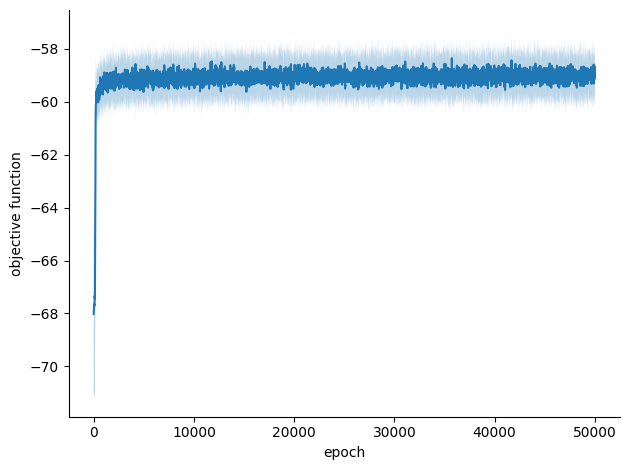

In [4]:
nb_tasks = 100
print(nb_tasks)
import matplotlib.pyplot as plt

loss_stats = loss_df.groupby('step').loss.agg(['mean', 'std'])
fig, ax = plt.subplots()
ax.plot(loss_stats.index, -loss_stats['mean'])
ax.fill_between(loss_stats.index, 
                -loss_stats['mean'] - loss_stats['std'], 
                -loss_stats['mean'] + loss_stats['std'],
                alpha=0.3)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xlabel('epoch')
ax.set_ylabel('objective function')
plt.tight_layout()
plt.savefig('figures/loss_epoch_feb2026_mastermind.pdf')
plt.show()

In [33]:
import numpy as np

# Define the parameter ranges
range_of_vols = [0.001, 0.01, 0.02, 0.05, 0.10]
range_of_ffs = [0.05, 0.1, 0.15, 0.2]

nb_tasks = 2000
vols_grid, ffs_grid= np.meshgrid(range_of_vols, range_of_ffs, indexing='ij')
vols, ffs= vols_grid.ravel(), ffs_grid.ravel()

nb_repeats = int(nb_tasks / len(vols)) + 1
vols = np.tile(vols, nb_repeats)[:nb_tasks]
ffs = np.tile(ffs, nb_repeats)[:nb_tasks]

nb_bins_volatility = len(range_of_vols)
nb_bins_falsefeedback = len(range_of_ffs)

In [34]:
from scipy.stats import spearmanr, pearsonr
import warnings
warnings.simplefilter("error", RuntimeWarning)
from tqdm import tqdm
nb_simul = 30
nb_trials = 1000

# performance
performance = np.zeros([nb_simul])
performance_stds = np.zeros([nb_simul])

# volatility
nus_native = np.zeros([nb_simul, nb_bins_volatility])
nus_learned = np.zeros([nb_simul, nb_bins_volatility])
nus_learned_stds = np.zeros([nb_simul, nb_bins_volatility])
nus_function_of_trials = np.zeros([nb_simul, nb_tasks, nb_trials])

# false feedback
false_positive_rate_native = np.zeros([nb_simul, nb_bins_falsefeedback])
false_positive_rate_learned = np.zeros([nb_simul, nb_bins_falsefeedback])
false_positive_rate_learned_stds = np.zeros([nb_simul, nb_bins_falsefeedback])
false_positive_rate_function_of_trials = np.zeros([nb_simul, nb_tasks, nb_trials])

for index in tqdm(range(1, nb_simul + 1)):

    self = Worker(
        Mastermind(n_trials=nb_trials),
        "results/source/saved_models",
        "mastermindGRU_id{0}".format(index),
    )

    self.load_model()

    np.random.seed(0)
    torch.manual_seed(0)
    self.env._generate_task_schedule(nb_tasks=nb_tasks, nus=vols, ffbs=ffs)
    result = self.evaluate(use_ground_truth=False)

    # volatility
    nus = self.env.nu.mean(axis=1)
    sorted_bins = np.array([0] + range_of_vols) + 1e-9
    digited_bins = np.digitize(nus, sorted_bins, right=True) - 1
    digited_bins[digited_bins == nb_bins_volatility] = nb_bins_volatility - 1 # bin nb_bins_volatility-1 is skipped
    for bin in range(nb_bins_volatility):
        nus_native[index - 1, bin] = self.env.nu[digited_bins == bin].mean()
        nus_learned[index - 1, bin] = result["params_transition"][digited_bins == bin, -1].mean(axis=0).detach().numpy()
        nus_learned_stds[index - 1, bin] = result["params_transition"][digited_bins == bin, -1].std(axis=0).detach().numpy()
    nus_function_of_trials[index - 1, :] = result["params_transition"].detach().numpy()

    # rewards x volatility
    chosen_correct_action = (result['actions'].detach().numpy() == self.env.correct_action)
    obtained_rewards = [chosen_correct_action[digited_bins == nu] for nu in range(nb_bins_volatility)]

    # false feedback
    false_positive_rate = self.env.ffb.mean(axis=1)
    sorted_bins_falsefeedback = np.array([0] + range_of_ffs) + 1e-9
    digited_bins_falsefeedback = np.digitize(false_positive_rate, sorted_bins_falsefeedback, right=True) - 1
    assert((digited_bins_falsefeedback != nb_bins_falsefeedback).all())
    digited_bins_falsefeedback[digited_bins_falsefeedback == nb_bins_falsefeedback] = nb_bins_falsefeedback - 1 # bin nb_bins_falsefeedback-1 is skipped
    for bin in range(nb_bins_falsefeedback):
        false_positive_rate_native[index - 1, bin] = self.env.ffb[digited_bins_falsefeedback == bin].mean()
        false_positive_rate_learned[index - 1, bin] = result['params_emission'][digited_bins_falsefeedback == bin, -1].mean(axis=0).detach().numpy()
        false_positive_rate_learned_stds[index - 1, bin] = result['params_emission'][digited_bins_falsefeedback == bin, -1].std(axis=0).detach().numpy()
    false_positive_rate_function_of_trials[index - 1, :] = result['params_emission'].detach().numpy()

    # rewards x false feedback
    chosen_correct_action = (result['actions'].detach().numpy() == self.env.correct_action)
    obtained_rewards = [chosen_correct_action[digited_bins_falsefeedback == ff] for ff in range(nb_bins_falsefeedback)]

    # reversal performance
    chosen_correct_action = (result['actions'].detach().numpy() == self.env.correct_action)
    performance[index - 1] = chosen_correct_action.mean()
    performance_stds[index - 1] = chosen_correct_action.std()

100%|██████████| 30/30 [06:10<00:00, 12.36s/it]


In [51]:
performance.mean()
import pickle
# load optimality results
[perf_opt, unique_vols_opt, unique_falsefeedback_opt, estimations_means_ff_opt, estimations_means_vol_opt] = pickle.load(open("result_optimality_processed.pkl", "rb"))
[_, self_opt] = pickle.load(open("result_optimality.pkl", "rb"))

In [ ]:
(self.env.correct_action == self_opt.env.correct_action).mean()

1.0

In [69]:
perf_opt.mean()

0.8109149999999999

In [75]:
mean_perf

0.80919155

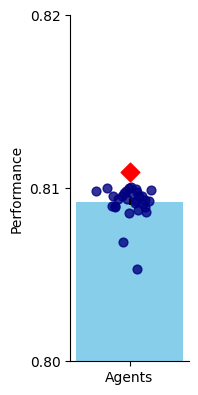

In [79]:
import matplotlib.pyplot as plt
import numpy as np

# Assume we have 30 agents, each with a performance score in `performance` (shape: (30,))
agent_indices = np.arange(len(performance))

# Calculate mean and SEM (standard error of the mean)
mean_perf = performance.mean()
sem_perf = performance.std(ddof=1) / np.sqrt(len(performance))

fig, ax = plt.subplots(figsize=(2, 4))
# Bar plot of average performance with SEM
ax.bar(0, mean_perf, width=0.5, color='skyblue', label='Mean performance', yerr=sem_perf, capsize=0, ecolor='black')

# Add jitter to the x-axis for better visibility
rng = np.random.default_rng(42)
jitter = rng.normal(loc=0, scale=0.08, size=performance.shape)

# Scatter plot of each agent's performance with jitter
ax.scatter(jitter, performance, color='navy', s=40, alpha=0.8, label='Agent performances')

# Add the perf_opt.mean() as a single diamond in a different color (red), without jitter
ax.scatter([0], [perf_opt.mean()], color='red', s=90, marker='D', label='Optimal mean performance', zorder=10)

ax.set_ylabel('Performance')
ax.set_xticks([0])
ax.set_xticklabels(['Agents'])

# Take out top and right edges
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.gca().set_yticks([0.8, 0.81, 0.82])
plt.gca().set_ylim(0.8, 0.82)
plt.savefig('figures/performance_mastermind.pdf')

/var/folders/5j/f0qqpk592x36fxmyl_8vbkw40000gp/T/ipykernel_64160/2066891034.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Blues', estimations_means.shape[1] + 2)  # +2 to avoid pure white


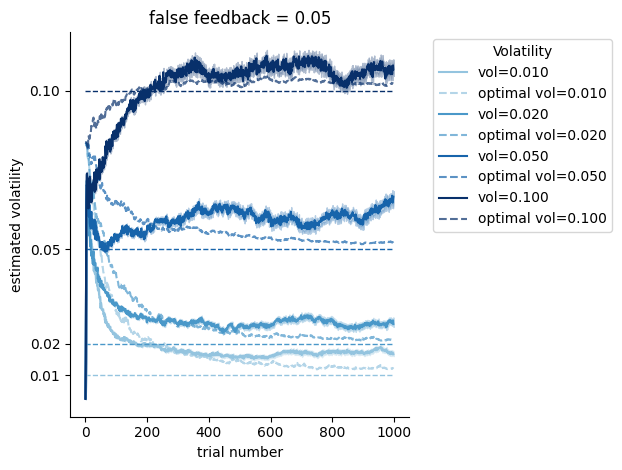

In [77]:
unique_vols = np.unique(vols)[1:]
assert(np.all(unique_vols_opt == unique_vols))
estimations_means = np.hstack([nus_function_of_trials[:, (vols==v) * (ffs==0.1)].mean(axis=1, keepdims=True) for v in unique_vols])

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Create a colormap with as many shades as unique_vols
cmap = cm.get_cmap('Blues', estimations_means.shape[1] + 2)  # +2 to avoid pure white

fig, ax = plt.subplots()
for i in range(estimations_means.shape[1]):
    color = cmap(i + 2)  # skip the lightest colors
    ax.plot(estimations_means[:, i, 1:1000].mean(axis=0), color=color, label=f'vol={unique_vols[i]:.3f}')
    ax.plot(estimations_means_vol_opt[i, 1:1000], color=color, linestyle='--', linewidth=1.5, label=f'optimal vol={unique_vols[i]:.3f}', alpha=0.7)
    ax.fill_between(np.arange(1, 1000), 
        estimations_means[:, i, 1:1000].mean(axis=0) - estimations_means[:, i, 1:1000].std(axis=0) / np.sqrt(estimations_means.shape[0]), 
        estimations_means[:, i, 1:1000].mean(axis=0) + estimations_means[:, i, 1:1000].std(axis=0) / np.sqrt(estimations_means.shape[0]), 
        color=color, alpha=0.3)
    
    ax.plot([0, 1000], [unique_vols[i], unique_vols[i]], color=color, linestyle='--', linewidth=1)
ax.set_xlabel('True volatility')
ax.legend(title="Volatility", bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_xlabel('trial number')
ax.set_ylabel('estimated volatility')
ax.set_title('false feedback = 0.05')
ax.set_yticks(unique_vols)
# Take out top and right edges
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('figures/volatility_trial_number_feb2026_mastermind.pdf')

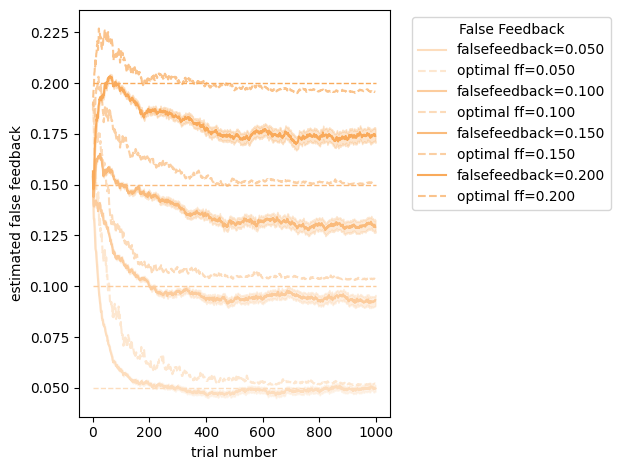

In [78]:
unique_falsefeedback = np.unique(ffs)
estimations_means = 1- np.hstack([false_positive_rate_function_of_trials[:, (ffs==v) * (vols==0.05)].mean(axis=1, keepdims=True) for v in unique_falsefeedback])

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Create a colormap gradient of "#F8993A"
base_color = "#F8993A"
# We'll make a light-to-dark gradient using the base color and white
colors = [mcolors.to_rgba(base_color, alpha=1.0)]
for i in range(1, estimations_means.shape[1] + 2):
    # Interpolate between white and base_color
    interp = i / (estimations_means.shape[1] + 2)
    color = mcolors.to_rgba(base_color, alpha=1.0)
    white = np.array([1, 1, 1, 1])
    color = tuple((1 - interp) * white + interp * np.array(color))
    colors.append(color)
# Use the list of colors as gradient

for i in range(estimations_means.shape[1]):
    color = colors[i + 2]  # skip the lightest colors (to avoid pure white)
    plt.plot(estimations_means[:, i, 1:1000].mean(axis=0), color=color, label=f'falsefeedback={unique_falsefeedback[i]:.3f}')
    plt.plot(estimations_means_ff_opt[i, 1:1000], color=color, linestyle='--', linewidth=1.5, label=f'optimal ff={unique_falsefeedback[i]:.3f}', alpha=0.7)
    plt.fill_between(np.arange(1, 1000), 
        estimations_means[:, i, 1:1000].mean(axis=0) - estimations_means[:, i, 1:1000].std(axis=0) / np.sqrt(estimations_means.shape[0]), 
        estimations_means[:, i, 1:1000].mean(axis=0) + estimations_means[:, i, 1:1000].std(axis=0) / np.sqrt(estimations_means.shape[0]), 
        color=color, alpha=0.3)
    plt.plot([0, 1000], [unique_falsefeedback[i], unique_falsefeedback[i]], color=color, linestyle='--', linewidth=1)
plt.xlabel('False Feedback Rate')
plt.legend(title="False Feedback", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel('trial number')
plt.ylabel('estimated false feedback')
plt.tight_layout()
plt.savefig('figures/falsefeedback_trial_number_feb2026_mastermind.pdf')

### reversal

In [11]:
from scipy.stats import spearmanr, pearsonr
import warnings
warnings.simplefilter("error", RuntimeWarning)
from tqdm import tqdm
nb_simul = 30
nb_trials = 1000
nb_tasks = 2000

# performance
performance = np.zeros([nb_simul, nb_trials])

np.random.seed(0)
first_combination = np.random.randint(0, 24, [nb_tasks])
end_combination = np.array([np.random.choice(np.delete(np.arange(24), c)) for c in first_combination])
correct_combinations = np.zeros([nb_tasks, nb_trials], dtype=int)
correct_combinations[:, :500] = first_combination[:, None]
correct_combinations[:, 500:] = end_combination[:, None]

for index in tqdm(range(1, nb_simul + 1)):

    self = Worker(
        Mastermind(n_trials=nb_trials),
        "results/source/saved_models",
        "mastermindGRU_id{0}".format(index),
    )

    self.load_model()

    np.random.seed(0)
    torch.manual_seed(0)
    self.env._generate_task_schedule(nb_tasks=nb_tasks, correct_combinations=correct_combinations, ffbs=[0.2] * len(correct_combinations))
    result = self.evaluate(use_ground_truth=False)
    
    performance[index - 1, :] = (result['actions'].detach().numpy() == self.env.correct_action).mean(axis=0)

100%|██████████| 30/30 [06:13<00:00, 12.45s/it]


In [12]:
# add optimality
import pickle
[result_rev, self_opt] = pickle.load(open("result_optimality_rev.pkl", "rb"))
_, selected_actions_opt, _ = result_rev
performance_opt = (selected_actions_opt == self.env.correct_action)

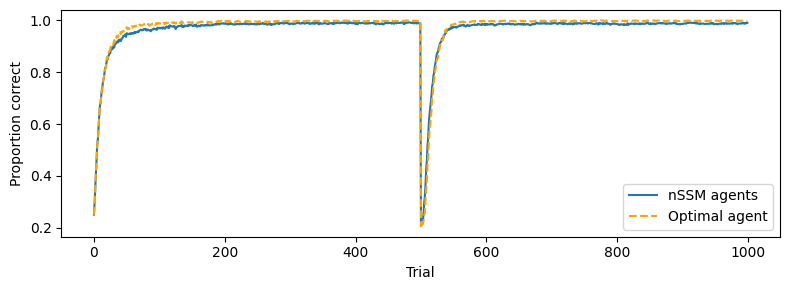

In [31]:
from matplotlib import pyplot as plt
import numpy as np

plt.figure(figsize=(8, 3))

# Calculate mean and SEM for nSSM agents
mean_nSSM = performance.T.mean(axis=1)
sem_nSSM = performance.T.std(axis=1) / np.sqrt(performance.shape[0])

# Plot nSSM agents with SEM as shaded region
x = np.arange(len(mean_nSSM))
plt.plot(x, mean_nSSM, label='nSSM agents')
plt.fill_between(x, mean_nSSM - sem_nSSM, mean_nSSM + sem_nSSM, alpha=0.3)

# Plot optimal agent as dashed line
mean_opt = performance_opt.T.mean(axis=1)
plt.plot(x, mean_opt, linestyle='--', color='orange', label='Optimal agent')

plt.legend()
plt.xlabel('Trial')
plt.ylabel('Proportion correct')
plt.tight_layout()
plt.savefig('figures/performance_rev_mastermind.pdf')

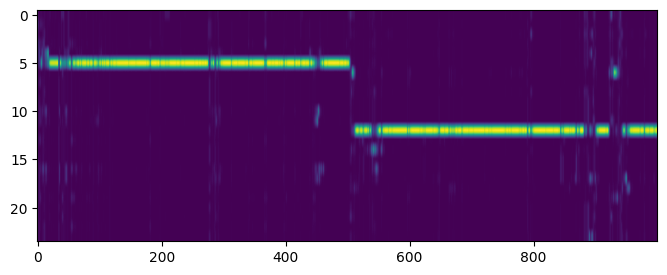

In [32]:
i_ = 21
imshow = torch.exp(result['log_predict_probs_all_trials'][i_] - torch.logsumexp(result['log_predict_probs_all_trials'][i_], dim=1)[:, None]).detach().numpy()
plt.figure(figsize=(8, 3))
plt.imshow(imshow.T, aspect='auto')
plt.savefig('figures/imshow_rev_mastermind.pdf')